# Note about the notebook
Below are stylings which work seemlessly if you are using the GitHub Dark theme in vscode. It is pretentious, I know.

# Information Visualization

Typically, information visualization is a subfield of "visualization" as a whole. It is the study of how to represent data and information in a visual format that is easy to understand and interpret. This can include charts, graphs, maps, and other visual representations of data. The goal of information visualization is to help people make sense of complex data sets and to communicate information effectively.

## Distinction from Scientific Visualization

In scientific visualization, the primary advancement is finding new ways to visualize data, partially very complex or high-dimensional data. In contrast, information visualization typically deals with:

IV is often used as a vehicle for communicating information to the three main audiences: General Public, Other Scientists, Yourself.

The primary point of this section is to highlight that while there is a lot of previous and partially complex work in the field, there are also many tools that can be used.

## Challenges

- **Format**: Depending on how you present the data, and where the plot needs to end up, you need to consider the shape of its presentation. For papers, you need to consider the print-size of the plot (in terms of the PDF file, not actual printing presses). For web pages, you need to consider that a rasterized version of the plot will have very distinct properties.
- **Purpose**: In both science communication and writing papers, the plot needs to enhance and provide a basis for your reasoning and arguments. However, if you are visualizing for yourself, the plot needs to make sense to you and be an expedient way to get information.
- **Accessibility**: The plot needs to be accessible to the audience. This not only includes the audience's ability to read and understand the plot but also whether they can actually SEE the plot.

## Matplotlib introduction

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
# disable RuntimeWarning
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
# markdown display
from IPython.display import display, Markdown, HTML
import math

## Anatomy of a plot

<img src="plot.png" width="600" alt="Anatomy of a plot" />

In [ ]:
# dark mode for matplotlib
primary_background = '#24292e'
primary_foreground = '#ffffff'
secondary_foreground = '#444444'
face_colour = "#579ec6"
flier_colour = "#f0a500"
line_colour = "#579ec6"
highlight_colour = "#6e0000"
plt.style.use('dark_background')
# set background colour to dark grey
plt.rcParams['axes.facecolor'] = primary_background
plt.rcParams['axes.edgecolor'] = primary_foreground
plt.rcParams['axes.labelcolor'] = primary_foreground
plt.rcParams['xtick.color'] = primary_foreground
plt.rcParams['ytick.color'] = primary_foreground
plt.rcParams['figure.facecolor'] = primary_background
plt.rcParams['figure.edgecolor'] = face_colour
plt.rcParams['savefig.facecolor'] = primary_background
plt.rcParams['savefig.edgecolor'] = primary_background
plt.rcParams['text.color'] = primary_foreground
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.color'] = line_colour
plt.rcParams['grid.color'] = line_colour
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['font.family'] = 'Arial'
# set display dpi for jupyter notebook
plt.rcParams['figure.dpi'] = 100

# Colour Space Theory

--> for colour combinations, see https://www.canva.com/colors/color-wheel/

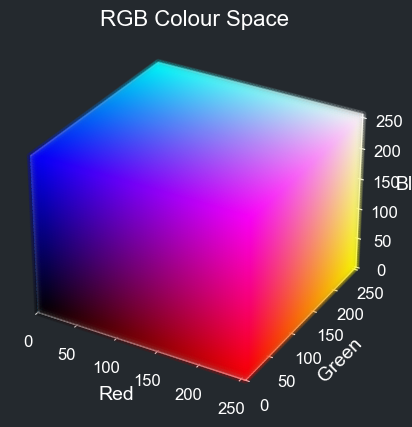

In [5]:
# RGB colour space
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
# set the limits of the axes
ax.set_xlim(0, 255)
ax.set_ylim(0, 255)
ax.set_zlim(0, 255)
# set the labels of the axes
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')
# set the title of the plot
ax.set_title('RGB Colour Space')
# plot the points in the RGB colour space
# create a grid of points in the RGB colour space
x = np.linspace(0, 255, 65)
y = np.linspace(0, 255, 65)
z = np.linspace(0, 255, 65)
# create a meshgrid of the points
X, Y, Z = np.meshgrid(x, y, z)
# create a scatter plot of the points in the RGB colour space
ax.scatter(X, Y, Z, c=np.array([X.flatten(), Y.flatten(), Z.flatten()]).T/255, marker='o', alpha=0.1)
# show the plot
plt.show()

## RGB Gradients

In [6]:
def rgb_to_hsl(rgb):
    r, g, b = rgb
    max_c = max(r, g, b)
    min_c = min(r, g, b)
    delta = max_c - min_c
    # Calculate lightness
    l = (max_c + min_c) / 2.0
    # Calculate saturation
    if delta == 0:
        s = 0
        h = 0
    else:
        if l < 0.5:
            s = delta / (max_c + min_c)
        else:
            s = delta / (2 - max_c - min_c)
        if max_c == r:
            h = (g - b) / delta % 6
        elif max_c == g:
            h = (b - r) / delta + 2
        else:
            h = (r - g) / delta + 4
        h *= 60
    return [int(h), int(s * 100), int(l * 100)]

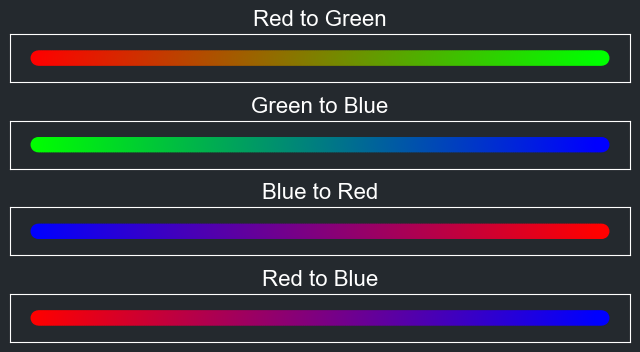

In [7]:
# display a set of gradients between two colours, interpolated through RGB space
fig,ax = plt.subplots(4, 1, figsize=(8, 4))

for sax in ax :
  # no grid lines
  sax.grid(False)
  # no ticks
  sax.set_xticks([])
  sax.set_yticks([])

# first gradient: red to green
x = np.linspace(0, 255, 256)
y = np.zeros_like(x)  # Ensure y has the same shape as x
# create a gradient from red to green
start = np.array([1.0, 0, 0, 1.0])
end = np.array([0, 1.0, 0, 1.0])
red_green_colours = np.array([start + (end - start) * i for i in np.linspace(0, 1, x.shape[0])])
# create a scatter plot of the points in the RGB colour space
ax[0].scatter(x, y, c=red_green_colours, marker='o', alpha=1.0, s=100)
ax[0].set_title('Red to Green')


# second gradient: green to blue
start = np.array([0, 1.0, 0, 1.0])
end = np.array([0, 0, 1.0, 1.0])
green_blue_colours = np.array([start + (end - start) * i for i in np.linspace(0, 1, x.shape[0])])
ax[1].scatter(x, y, c=green_blue_colours, marker='o', alpha=1.0, s=100)
ax[1].set_title('Green to Blue')

# third gradient: blue to red
start = np.array([0, 0, 1.0, 1.0])
end = np.array([1.0, 0, 0, 1.0])
blue_red_colours = np.array([start + (end - start) * i for i in np.linspace(0, 1, x.shape[0])])
ax[2].scatter(x, y, c=blue_red_colours, marker='o', alpha=1.0, s=100)
ax[2].set_title('Blue to Red')

# fourth gradient: red to blue
start = np.array([1.0, 0, 0, 1.0])
end = np.array([0, 0, 1.0, 1.0])
red_blue_colours = np.array([start + (end - start) * i for i in np.linspace(0, 1, x.shape[0])])
ax[3].scatter(x, y, c=red_blue_colours, marker='o', alpha=1.0, s=100)
ax[3].set_title('Red to Blue')

fig.subplots_adjust(hspace=0.8)


# show the plot
plt.show()


## What do we see?

### Gradient Properties

The gradient is an interpolation between colours. This is commonly used to map data to lines or surfaces - for the purposes of not only having the line itself, but also an idea of an auxiliary data that changes long the line.

These gradients above are mapped using RGB - this means that in the middle, we will inevitably have a colour that appears a little darker. Let us have a closer look:

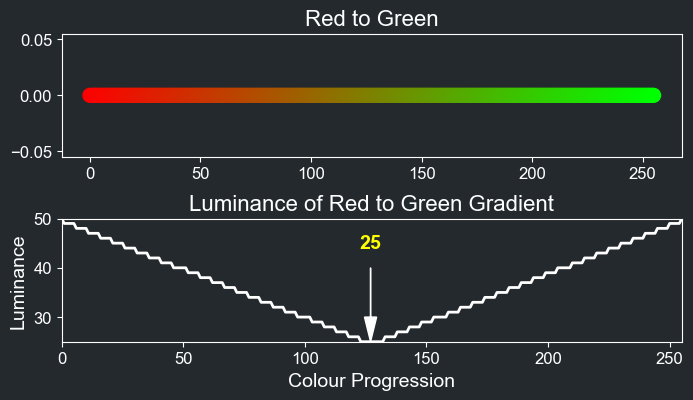

In [8]:
# display the red-green gradient again:
fig,ax = plt.subplots(2, 1, figsize=(8, 4))
# 0.5 inch spacing between the plots
fig.subplots_adjust(hspace=0.5)
# make axis lines visible
ax[1].spines['top'].set_visible(True)
ax[1].spines['bottom'].set_visible(True)
ax[1].spines['left'].set_visible(True)
ax[1].spines['right'].set_visible(True)
ax[1].spines['top'].set_color('white')
ax[1].spines['bottom'].set_color('white')
ax[1].spines['left'].set_color('white')
ax[1].spines['right'].set_color('white')
# first gradient: red to green
x = np.linspace(0, 255, 256)
y = np.zeros_like(x)  # Ensure y has the same shape as x
# create a gradient from red to green
start = np.array([1.0, 0, 0])
end = np.array([0.0, 1.0, 0.0])
red_green_colours = np.array([start + (end - start) * i for i in np.linspace(0, 1, x.shape[0])])
# create a scatter plot of the points in the RGB colour space
ax[0].scatter(x, y, c=red_green_colours, marker='o', alpha=1.0, s=100)
ax[0].set_title('Red to Green')

# display the Luminance of the red-green gradient as a line plot
luminance = np.zeros_like(x)
for i in range(len(x)):
    # calculate the luminance of the red-green gradient
    luminance[i] = rgb_to_hsl(red_green_colours[i])[2]
ax[1].plot(x, luminance, color='white')
# set the title of the plot
ax[1].set_title('Luminance of Red to Green Gradient')
# set the x and y limits of the plot
ax[1].set_xlim(0, 255)
ax[1].set_ylim(25, 50)
# set the x and y labels of the plot
ax[1].set_xlabel('Colour Progression')
ax[1].set_ylabel('Luminance')
# number in the middle top of the ax[1] plot with the mid value
ax[1].text(127, 45, str(int(luminance[127])), color="yellow", fontsize=14, ha='center', va='center', fontweight='bold')
# arrow down to the actual value
ax[1].arrow(127, 40, 0, -10, head_width=5, head_length=5, fc='white', ec='white')
# show the plot
plt.show()

## What does Luminance mean here?

This is the total value that measures the brightness of a colour in terms of its specific contrast.

Example: Bright red would be `C = RGB(255, 128, 128)` but full red is `C = RGB(255, 0, 0)`. The luminance of the first colour is `L = 0.5` and the luminance of the second colour is `L = 1.0`. This means that the first colour is half as luminant as the second colour. The colour yellow above is `C = RGB(127, 127, 0)` and has a luminance of `L = 0.5` --> This is partially why it appears a little darker.

Often times, colour maps will exclusively interpolate through the *hue* of the colour:

In [9]:
def hsl_to_rgb(h, s, l):
    """
    Convert HSL to RGB
    :param h: Hue (0-360)
    :param s: Saturation (0-1)
    :param l: Lightness (0-1)
    :return: RGB tuple (r, g, b) where each value is between 0 and 255
    """
    if s == 0:
        r = g = b = int(l * 255)
    else:
        def hue_to_rgb(p, q, t):
            if t < 0:
                t += 1
            if t > 1:
                t -= 1
            if t < 1/6:
                return p + (q - p) * 6 * t
            if t < 1/2:
                return q
            if t < 2/3:
                return p + (q - p) * (2/3 - t) * 6
            return p

        q = l * (1 + s) if l < 0.5 else l + s - l * s
        p = 2 * l - q
        r = int(hue_to_rgb(p, q, h / 360) * 255)
        g = int(hue_to_rgb(p, q, h / 360 + 1/3) * 255)
        b = int(hue_to_rgb(p, q, h / 360 - 1/3) * 255)

    return r, g, b

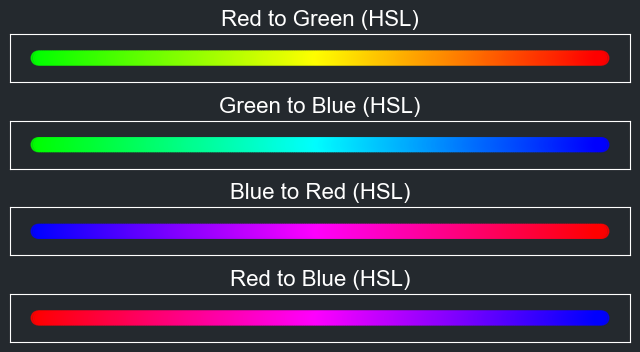

In [10]:
# display a set of gradients between two colours, interpolated through HSL space
fig,ax = plt.subplots(4, 1, figsize=(8, 4))

for sax in ax :
  # no grid lines
  sax.grid(False)
  # no ticks
  sax.set_xticks([])
  sax.set_yticks([])

# first gradient: red to green
x = np.linspace(0, 255, 256)
y = np.zeros_like(x)  # Ensure y has the same shape as x
# create a gradient from red to green
start = np.array([0, 1.0, 0.5])
end = np.array([120, 1.0, 0.5])
red_green_colours = np.array([start + (end - start) * i for i in np.linspace(0, 1, x.shape[0])])
# normalize hue values to the range [0, 360]
red_green_colours[:, 0] = np.clip(red_green_colours[:, 0], 0, 360)
# convert HSL to RGB
red_green_colours_rgb = np.array([hsl_to_rgb(h, s, l) for h, s, l in red_green_colours]) / 255.0
# create a scatter plot of the points in the RGB colour space
ax[0].scatter(x, y, c=red_green_colours_rgb, marker='o', alpha=0.8, s=100)
ax[0].set_title('Red to Green (HSL)')

# second gradient: green to blue
start = np.array([360, 1.0, 0.5])
end = np.array([240, 1.0, 0.5])
green_blue_colours = np.array([start + (end - start) * i for i in np.linspace(0, 1, x.shape[0])])
green_blue_colours[:, 0] = np.clip(green_blue_colours[:, 0], 0, 360)
green_blue_colours_rgb = np.array([hsl_to_rgb(h, s, l) for h, s, l in green_blue_colours]) / 255.0
ax[1].scatter(x, y, c=green_blue_colours_rgb, marker='o', alpha=0.8, s=100)
ax[1].set_title('Green to Blue (HSL)')

# third gradient: blue to red
start = np.array([240, 1.0, 0.5])
end = np.array([120, 1.0, 0.5])
blue_red_colours = np.array([start + (end - start) * i for i in np.linspace(0, 1, x.shape[0])])
blue_red_colours[:, 0] = np.clip(blue_red_colours[:, 0], 0, 360)
blue_red_colours_rgb = np.array([hsl_to_rgb(h, s, l) for h, s, l in blue_red_colours]) / 255.0
ax[2].scatter(x, y, c=blue_red_colours_rgb, marker='o', alpha=0.8, s=100)
ax[2].set_title('Blue to Red (HSL)')

# fourth gradient: red to blue
start = np.array([120, 1.0, 0.5])
end = np.array([240, 1.0, 0.5])
red_blue_colours = np.array([start + (end - start) * i for i in np.linspace(0, 1, x.shape[0])])
red_blue_colours[:, 0] = np.clip(red_blue_colours[:, 0], 0, 360)
red_blue_colours_rgb = np.array([hsl_to_rgb(h, s, l) for h, s, l in red_blue_colours]) / 255.0
ax[3].scatter(x, y, c=red_blue_colours_rgb, marker='o', alpha=0.8, s=100)
ax[3].set_title('Red to Blue (HSL)')



fig.subplots_adjust(hspace=0.8)


plt.show()


## HSL Colour Space

### It looks like a cylinder:

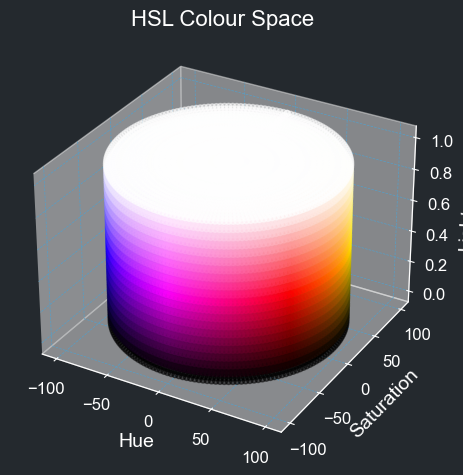

In [11]:
# HSL colour space
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
# set the labels of the axes
ax.set_xlabel('Hue')
ax.set_ylabel('Saturation')
ax.set_zlabel('Lightness')
# set the title of the plot
ax.set_title('HSL Colour Space')
# plot the points in the HSV colour space
H_steps = np.arange(0, 361, 2)
S_steps = np.arange(0, 101, 5)
L_steps = np.arange(0, 101, 5)
H_grid, S_grid, L_grid = np.meshgrid(H_steps, S_steps, L_steps, indexing='ij')
H_flat = H_grid.flatten()
S_flat = S_grid.flatten()
L_flat = L_grid.flatten()
x = S_flat * np.sin(np.radians(H_flat))
y = S_flat * np.cos(np.radians(H_flat))
z = L_flat / 100
colors = [[h,s,l] for h,s,l in zip(H_flat, S_flat, L_flat)]
# Convert HSL to RGB for each point
colors = [hsl_to_rgb(h, s / 100, l / 100) for h, s, l in zip(H_flat, S_flat, L_flat)]
colors = [(r / 255, g / 255, b / 255) for r, g, b in colors]  # Normalize RGB values to [0, 1]
# create a scatter plot of the points in the HSV colour space
ax.scatter(x, y, z, c=colors, marker='o', alpha=0.5)
# show the plot
plt.tight_layout()
plt.show()

## Colourmaps in Matplotlib



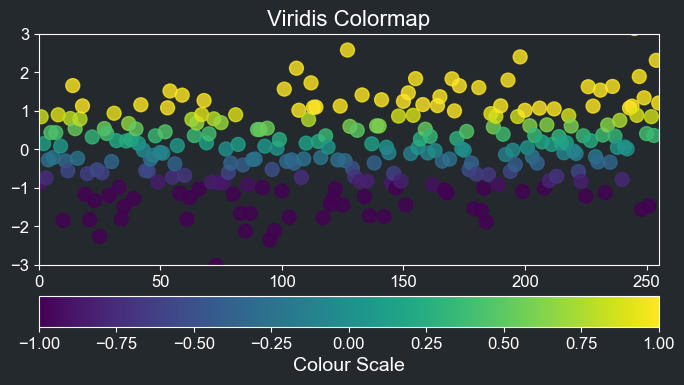

In [12]:
# Example of a colourmap plot

from matplotlib import colormaps as cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig,ax = plt.subplots(1, 1, figsize=(8, 4))

# plot scatter data

x = np.linspace(0, 255, 256)
y = np.random.normal(0, 1, 256)

# use the viridis colormap
cmap = cm['viridis']
norm = Normalize(vmin=-1, vmax=1)
# create a ScalarMappable object
sm = ScalarMappable(cmap=cmap, norm=norm)
# set the color of the points based on the x value
colors = sm.to_rgba(y)
# create a scatter plot of the points in the RGB colour space
ax.scatter(x, y, c=colors, marker='o', alpha=0.8, s=100)
# set the title of the plot
ax.set_title('Viridis Colormap')
# set the x and y limits of the plot
ax.set_xlim(0, 255)
ax.set_ylim(-3, 3)
# set the x and y labels of the plot
# plot the colourmap scale underneath
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.1)
cbar.set_label('Colour Scale')
plt.show()

# Basic Plotting

## Basic Plotting with Matplotlib

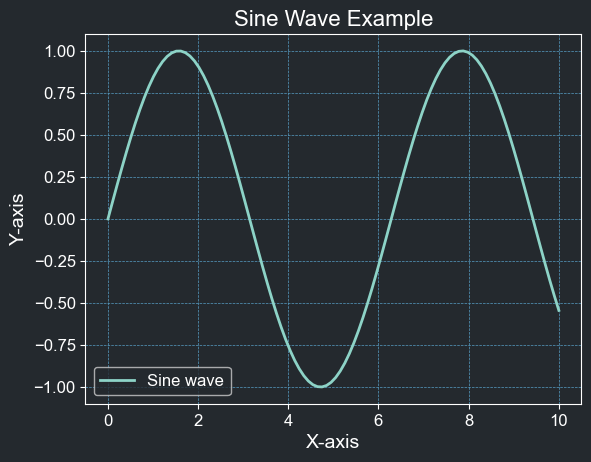

In [13]:
x = np.linspace(0, 10, 100)
y = np.sin(x)
plt.plot(x, y, label="Sine wave")
plt.title('Sine Wave Example')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True)
plt.show()

## Line Plot vs Scatter Plot

### Central Question: Is your data continuous or discrete?

### Related question: What <span style="color:#F55">disturbance</span> to the measurement do you accept while holdong onto the <span style="color:#55F">continuous</span> assumption?

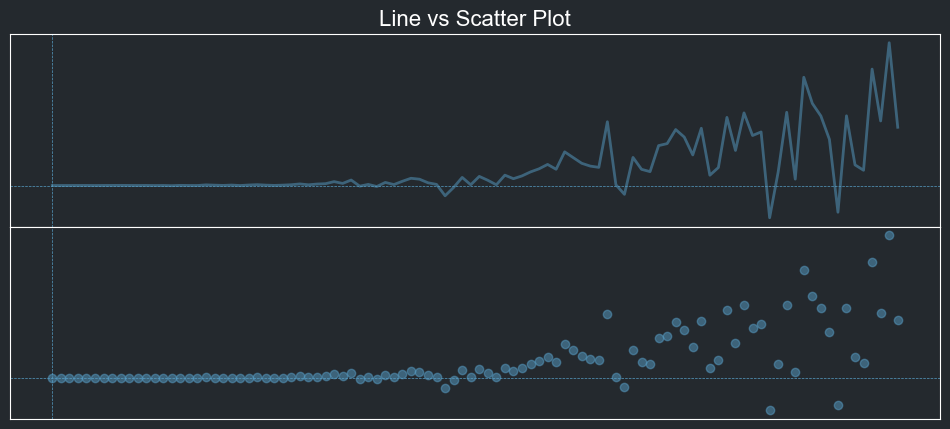

In [14]:
# Line plot vs scatter plot
fig,ax = plt.subplots(2, 1, figsize=(12, 5))
# no space between the plots
fig.subplots_adjust(hspace=0)

for sax in ax :
  # no grid lines
  sax.grid(False)
  # no ticks
  sax.set_xticks([])
  sax.set_yticks([])
  # horizontal line at y=0
  sax.axhline(0, color=line_colour, linewidth=0.5, linestyle='--')
  # vertical line at x=0
  sax.axvline(0, color=line_colour, linewidth=0.5, linestyle='--')

x = np.linspace(0, 20, 100)
# polynomial with strong noise that is proportial to the y value
y = 0.5 * x**3 - 2 * x**2 + 3 * x + 1
y = [y[i] + np.random.normal(0, 1.0 * y[i]) for i in range(len(y))]
# create a line plot of the points
ax[0].plot(x, y, color=line_colour, alpha=0.5)
# create a scatter plot of the points
ax[1].scatter(x, y, color=line_colour, alpha=0.5)
# set the title of the plot
ax[0].set_title('Line vs Scatter Plot')

plt.show()

# Boxplot figures

## What does a boxplot do?

A boxplot is a standardized way of displaying the distribution of data based on a five-number summary ("minimum", first quartile (Q1), median, third quartile (Q3), and "maximum").

A boxplot can also highlight outliers in the dataset.

## What is a boxplot NOT good for?

Different modes: If the underlying probability distribution is bimodal or multimodal, the boxplot will not show this, or struggle to show this.

This can result in a misleading representation of the data, showing a larger spread than is actually the case.



ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

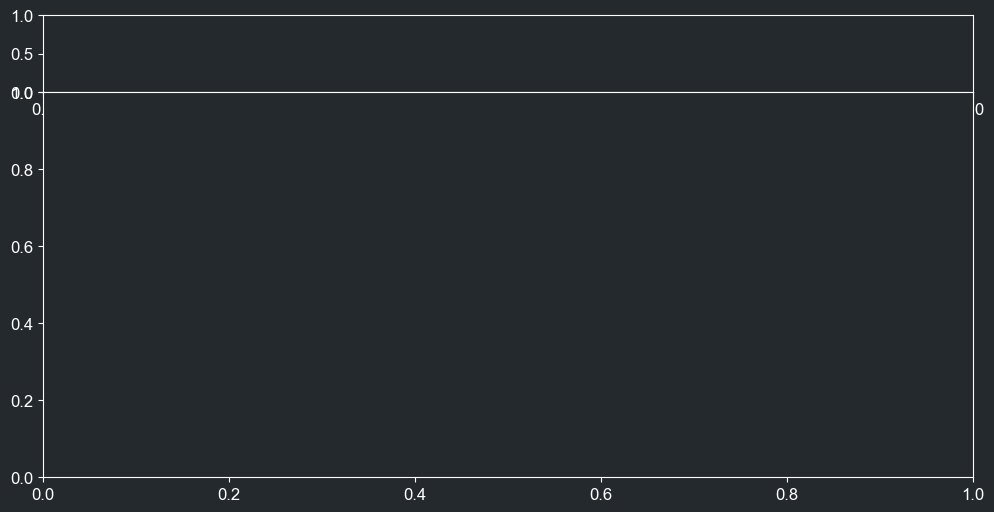

In [23]:
import functools
# small selection of density functions
density_functions = {
    'Normal': functools.partial(stats.norm.pdf, loc=0.5, scale=0.2),
    'Uniform': stats.uniform.pdf,
    'Exponential': functools.partial(stats.expon.pdf, scale=1),
    'Log-Normal': functools.partial(stats.lognorm.pdf, s=0.954, scale=np.exp(0)),
    #'Gamma': functools.partial(stats.gamma.pdf, a=9, scale=0.5),
    'Beta': functools.partial(stats.beta.pdf, a=2, b=5),
    'Weibull': functools.partial(stats.weibull_min.pdf, c=3),
    'Chi-Squared': functools.partial(stats.chi2.pdf, df=2),
    'bimodal': lambda x: 0.5 * stats.norm.pdf(x, loc=0.3, scale=0.1) + 0.5 * stats.norm.pdf(x, loc=0.7, scale=0.1)
}
quantile_functions = {
    'Normal': functools.partial(stats.norm.ppf, loc=0.5, scale=0.2),
    'Uniform': stats.uniform.ppf,
    'Exponential': functools.partial(stats.expon.ppf, scale=1),
    'Log-Normal': functools.partial(stats.lognorm.ppf, s=0.954, scale=np.exp(0)),
    #'Gamma': functools.partial(stats.gamma.ppf, a=9, scale=0.5),
    'Beta': functools.partial(stats.beta.ppf, a=2, b=5),
    'Weibull': functools.partial(stats.weibull_min.ppf, c=3),
    'Chi-Squared': functools.partial(stats.chi2.ppf, df=2),
    'bimodal': lambda p: 0.3 + 0.1 * np.random.normal(0, 1) if p < 0.5 else 0.7 + 0.1 * np.random.normal(0, 1)
}
# Generate x values for the density functions
x_values = np.linspace(-1, 3, 200)
# generate random points in the range of 0 to 1
in_d_values = np.random.uniform(0.0, 1.0, 100)
# Create a figure with a boxplot on top and a choice of three density functions below
fig, ax = plt.subplots(2, 1, figsize=(12, 6), height_ratios=[1, 5])
# no space between the plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)
# random choice of function
key = np.random.choice(list(density_functions.keys()))
# transform the random points to the quantile space
d_values = quantile_functions[key](in_d_values)
# first, background scatter
ax[0].scatter(d_values, np.random.uniform(0.9,1.1,d_values.shape), alpha=0.5, color='grey', s=10)
# Create a boxplot
ax[0].boxplot(d_values, vert=False, patch_artist=True)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_xlim(-1, 3)
ax[0].set_ylim(0.9, 1.1)
# remove axes text and lines
ax[0].spines['top'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
ax[0].spines['left'].set_visible(False)
ax[0].spines['right'].set_visible(False)
# plot the correct density function and two others
key_other1 = np.random.choice(list(density_functions.keys() - [key]))
key_other2 = np.random.choice(list(density_functions.keys() - [key, key_other1]))
colors = ['#FF5733', '#33FF57', '#3357FF']
y_0 = density_functions[key](x_values)
y_1 = density_functions[key_other1](x_values)
y_2 = density_functions[key_other2](x_values)
# replace NaN and -inf with 0, and inf with 1
y_0 = np.nan_to_num(y_0, nan=0.0, posinf=1.0)
y_1 = np.nan_to_num(y_1, nan=0.0, posinf=1.0)
y_2 = np.nan_to_num(y_2, nan=0.0, posinf=1.0)
# make all trapezoid values equal to 1
y_0 = y_0 / np.trapezoid(y_0, x_values)
y_1 = y_1 / np.trapezoid(y_1, x_values)
y_2 = y_2 / np.trapezoid(y_2, x_values)
# plot the density functions
ax[1].plot(x_values, y_0, color=colors[0], label=key)
ax[1].plot(x_values, y_1, color=colors[1], label=key_other1)
ax[1].plot(x_values, y_2, color=colors[2], label=key_other2)
# set the title of the plot
ax[1].set_title('Density Functions')
# hide axis ticks
ax[1].set_xticks([])
ax[1].set_yticks([])
# show the axis lines here
ax[1].spines['bottom'].set_visible(True)
ax[1].spines['left'].set_visible(True)
ax[1].spines['bottom'].set_color('white')
ax[1].spines['left'].set_color('white')
# show
ax[1].legend()
# anchor legend to the center right outside of the plot
ax[1].legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize=14)
plt.tight_layout()
plt.show()
# Display extra information about the distribution, in the next cell as markdown details tag
display(HTML("<details style='font-size:14pt;'><summary>Click to see the distribution details</summary><h2>Distribution: "+key+"</h2></details>"))


# Boxplot vs. Violin plot

### Violin plot: Shape-description, Everything included, fewer markers

### Boxplot: Quantile description, Outlier excluded (but marked), less "density" information

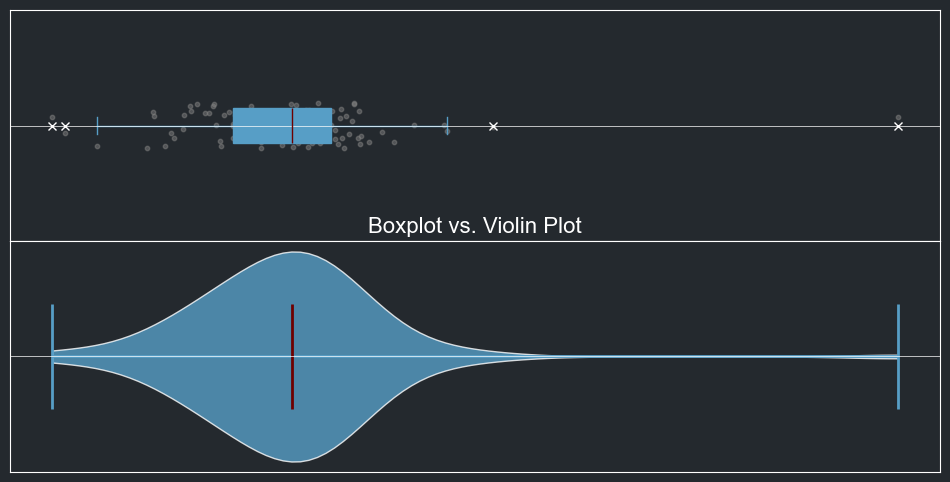

In [16]:
# Boxplot vs. Violin plot
x = np.linspace(0, 10, 100)
y = np.random.normal(np.random.uniform(-0.5,0.5), 1, 100)
# seed outliers
y[::10] = np.random.normal(np.random.uniform(0.0,1.5), 3.5, 10)
# Create a figure with a boxplot on top and a violin plot below
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
# no space between the plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)
# Create a scatter background
ax[0].scatter(y, np.random.uniform(0.9,1.1,y.shape), alpha=0.5, color='grey', s=10, marker='o')
# Create a boxplot
ax[0].boxplot(y, vert=False, patch_artist=True, 
              boxprops=dict(facecolor=face_colour, color=line_colour),
              medianprops=dict(color=highlight_colour),
              whiskerprops=dict(color=line_colour),
              capprops=dict(color=line_colour),
              flierprops=dict(markerfacecolor=flier_colour, marker='x'))
# create a violin plot with custom colours
parts = ax[1].violinplot(y, vert=False, showmeans=False, showmedians=True,
             bw_method=0.5, points=100, widths=0.5,
             showextrema=True)

# customize the colours of the violin plot
for pc in parts['bodies']:
  pc.set_facecolor('lightgreen')
  pc.set_edgecolor('white')
  pc.set_alpha(0.8)

if 'cmedians' in parts:
  parts['cmedians'].set_color(highlight_colour)
if 'cbars' in parts:
  parts['cbars'].set_color(line_colour)
if 'cmins' in parts:
  parts['cmins'].set_color(line_colour)
if 'cmaxes' in parts:
  parts['cmaxes'].set_color(line_colour)
# set the face colour of the violin plot's body
for pc in parts['bodies']:
    pc.set_facecolor(face_colour)
# set the title of the plot
ax[1].set_title('Boxplot vs. Violin Plot')
# graph information except lines
for sax in ax:
  sax.grid(False)
  sax.set_xticks([])
  sax.set_yticks([])
  # grey line through the middle of the plot
  sax.axhline(1, color='white', lw=0.5)
plt.show()

# Boxplot vs Bar chart
### Boxplot: Distribution of data, outliers included
### Bar chart: Direct density sampling, very wordy

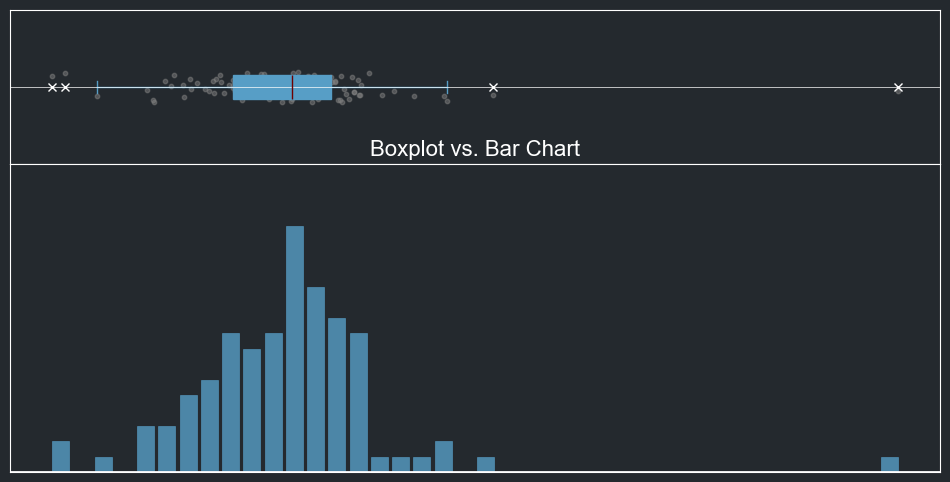

In [17]:
# Comparison boxplot vs bar chart
fig, ax = plt.subplots(2, 1, figsize=(12, 6), height_ratios=[1, 2])
# no space between the plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)
# Create a scatter background
ax[0].scatter(y, np.random.uniform(0.9,1.1,y.shape), alpha=0.5, color='grey', s=10, marker='o')
# Create a boxplot
ax[0].boxplot(y, vert=False, patch_artist=True, 
              boxprops=dict(facecolor=face_colour, color=line_colour),
              medianprops=dict(color=highlight_colour),
              whiskerprops=dict(color=line_colour),
              capprops=dict(color=line_colour),
              flierprops=dict(markerfacecolor=flier_colour, marker='x'))
# Create a histogram
ax[1].hist(y, bins=40, color=face_colour, alpha=0.8, edgecolor=line_colour, linewidth=0.5,
            histtype='bar', orientation='vertical',
            cumulative=False, density=False,
            align='mid', rwidth=0.8)
# set the title of the plot
ax[1].set_title('Boxplot vs. Bar Chart')
# graph information except lines
for sax in ax:
  sax.grid(False)
  sax.set_xticks([])
  sax.set_yticks([])
ax[0].axhline(1, color='white', lw=0.5)
ax[1].axhline(0.0, color='white', lw=2.0)
ax[1].set_ylim(0, 20)
plt.show()

# Manual Typesetting

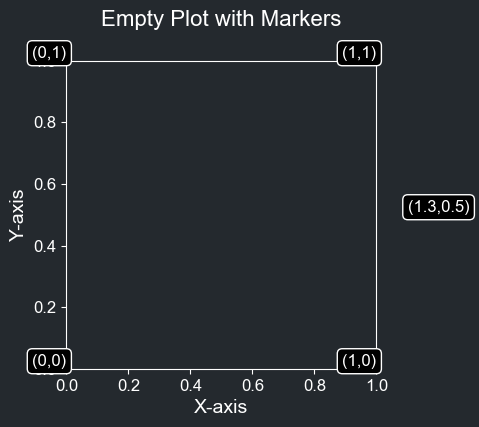

In [18]:
# generate an empty plot of size 4x4
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fontdict = {
    'fontsize': 12,
    'color': primary_foreground,
}
# show a text box at each corner
ax.text(0.0, 1.0, "(0,1)", fontsize=12, ha='right', va='bottom', fontdict=fontdict, bbox=dict(boxstyle='round,pad=0.3', edgecolor='white', facecolor='black'))
ax.text(1.0, 1.0, "(1,1)", fontsize=12, ha='right', va='bottom', fontdict=fontdict, bbox=dict(boxstyle='round,pad=0.3', edgecolor='white', facecolor='black'))
ax.text(0.0, 0.0, "(0,0)", fontsize=12, ha='right', va='bottom', fontdict=fontdict, bbox=dict(boxstyle='round,pad=0.3', edgecolor='white', facecolor='black'))
ax.text(1.0, 0.0, "(1,0)", fontsize=12, ha='right', va='bottom', fontdict=fontdict, bbox=dict(boxstyle='round,pad=0.3', edgecolor='white', facecolor='black'))
ax.text(1.3, 0.5, "(1.3,0.5)", fontsize=12, ha='right', va='bottom', fontdict=fontdict, bbox=dict(boxstyle='round,pad=0.3', edgecolor='white', facecolor='black'))

ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
# edge color to primary_foreground
for sax in ax.spines.values():
    sax.set_edgecolor(primary_foreground)

ax.text(0.5, 1.1, 'Empty Plot with Markers', fontsize=16, ha='center', va='bottom')


plt.show()

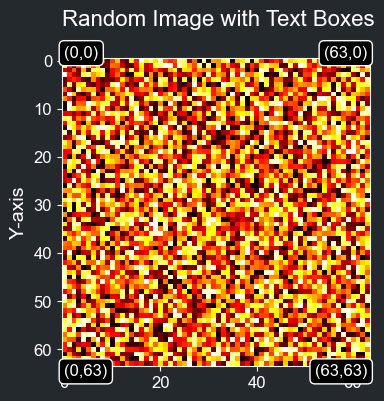

In [19]:
# generate a random image of size
size_x = 64
size_y = 64
img_data = np.random.rand(size_x, size_y)
# Create a figure and axis
fig, ax = plt.subplots(figsize=(4, 4))
# Display the image
ax.imshow(img_data, cmap='hot', interpolation='nearest')
# display a text box at each corner
ax.text(0.0, size_y - 1, "(0,{})".format(size_y - 1), fontsize=12, ha='left', va='top', bbox=dict(boxstyle='round,pad=0.3', edgecolor='white', facecolor='black'))
ax.text(size_x - 1, size_y - 1, "({},{})".format(size_x - 1, size_y - 1), fontsize=12, ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3', edgecolor='white', facecolor='black'))
ax.text(0.0, 0.0, "(0,0)", fontsize=12, ha='left', va='bottom', bbox=dict(boxstyle='round,pad=0.3', edgecolor='white', facecolor='black'))
ax.text(size_x - 1, 0.0, "({},0)".format(size_x - 1), fontsize=12, ha='right', va='bottom', bbox=dict(boxstyle='round,pad=0.3', edgecolor='white', facecolor='black'))
#x.set_title('Random Image with Text Boxes', pad=20)
ax.text(size_x / 2, -size_y / 10, 'Random Image with Text Boxes', fontsize=16, ha='center', va='bottom')
ax.set_ylabel('Y-axis')
plt.show()

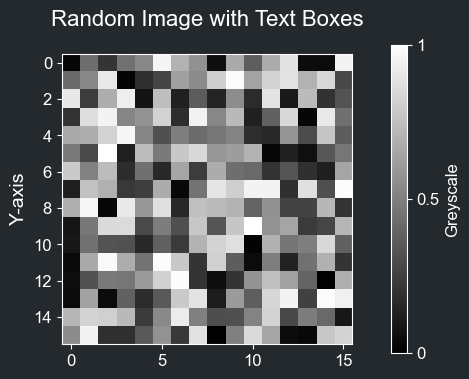

In [20]:
# generate a random image of size 16x16
img_data = np.random.rand(16, 16)
# Create a figure and axis
fig, ax = plt.subplots(figsize=(5, 5))
# Display the image
ax.imshow(img_data, cmap='gray', interpolation='nearest')
ax.set_title('Random Image with Text Boxes', pad=20)
ax.set_ylabel('Y-axis')

# generate a legend from the greyscale cmap
cmap = plt.get_cmap('gray')
# create a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])
# create a colorbar with the same size as the image
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.1, shrink=0.8)
# set the ticks of the colorbar
cbar.set_ticks([0, 0.5, 1])
# set the tick labels of the colorbar
cbar.set_ticklabels(['0', '0.5', '1'])
# set the label of the colorbar
cbar.set_label('Greyscale', fontsize=12, color=primary_foreground)

plt.show()

# Geospatial Data

## What does it look like?

Generally: Geospatial data is about the location of data points on the map. There are many projections and such, but primarily it is about map-like data.

Geopandas is a package that can parse some of these informations and use them to plot data on a map. It is not the only package that can do this! You should check what works best for you.

In [21]:
# Example geospatial plot for germany
import geopandas as gpd
import matplotlib.patheffects as PathEffects
# Path to the extracted shapefile
shapefile_path = "naturalearth_data/ne_10m_admin_0_countries.shp"
# Load the shapefile
world = gpd.read_file(shapefile_path)
# Use the correct column name for filtering
germany = world[world['NAME'] == 'Germany']
# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 8))
# Display the map
germany.boundary.plot(ax=ax, color='black', linewidth=1, facecolor=face_colour)
# Set the title and labels
ax.set_title('Map of Germany', fontsize=16, color=primary_foreground)
ax.set_xlabel('Longitude', fontsize=12, color=primary_foreground)
ax.set_ylabel('Latitude', fontsize=12, color=primary_foreground)

leipzig_coords = (12.3731, 51.3397)  # Longitude, Latitude of Leipzig
ax.plot(leipzig_coords[0], leipzig_coords[1], 'ro', markersize=8, label='Leipzig')
# Add a label for Leipzig
txt = ax.text(leipzig_coords[0], leipzig_coords[1] + 0.2, 'You', fontsize=14, color='white', ha='center', va='center')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='black')])
ax.set_facecolor(primary_background)
# Set the x and y limits
ax.set_xlim(germany.total_bounds[0], germany.total_bounds[2])
ax.set_ylim(germany.total_bounds[1], germany.total_bounds[3])
# Set the ticks and labels
ax.set_xticks(np.arange(germany.total_bounds[0], germany.total_bounds[2], 1))
ax.set_yticks(np.arange(germany.total_bounds[1], germany.total_bounds[3], 1))
# Format x-tick labels as XX°XX'
xticks = np.arange(germany.total_bounds[0], germany.total_bounds[2], 1)
yticks = np.arange(germany.total_bounds[1], germany.total_bounds[3], 1)
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels([f"{int(tick)}°{int((tick - int(tick)) * 60):02d}'" for tick in xticks], fontsize=10, color=primary_foreground)
ax.set_yticklabels([f"{int(tick)}°{int((tick - int(tick)) * 60):02d}'" for tick in yticks], fontsize=10, color=primary_foreground)
# Show the plot
plt.show()

DataSourceError: naturalearth_data/ne_10m_admin_0_countries.shp: No such file or directory

# Export Options

## Exporting to PDF

PDF Format is a portable format that will work on many different systems and also supports vector graphics.

## Exporting to PNG

PNG is a raster format that is not as portable as PDF, but it is widely used and supported. It is also a good choice for web graphics and images that need to be displayed on screens.

## Exporting to SVG

SVG is a vector format that is widely used for web graphics and images. It is also a good choice for images that need to be displayed on screens, as it supports transparency and can be scaled without losing quality.

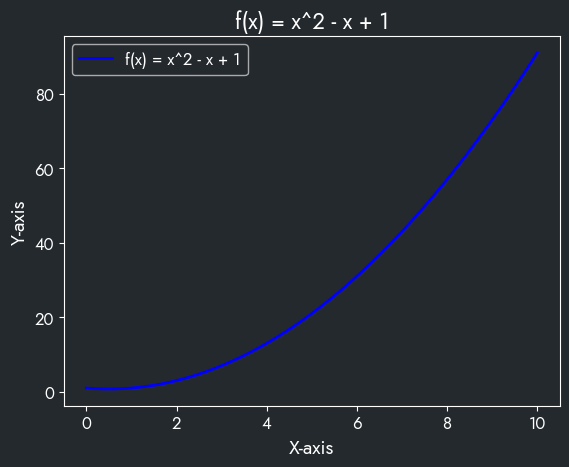

In [ ]:
# export options
# make a new line figure with f(x) = x^2 - x + 1
x = np.linspace(0, 10, 100)
y = x**2 - x + 1
fig, ax = plt.subplots()
ax.plot(x, y, color='blue', label='f(x) = x^2 - x + 1')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_title('f(x) = x^2 - x + 1')
ax.legend()
# make sure that plots/ is created
import os
if not os.path.exists('plots'):
  os.mkdir('plots')
# Save the figure in different formats
fig.savefig('plots/plot.pdf', dpi=300, bbox_inches='tight')  # PDF format
fig.savefig('plots/plot.svg', dpi=300, bbox_inches='tight')  # SVG format
#fig.savefig('plots/plot.eps', dpi=300, bbox_inches='tight')  # EPS format
fig.savefig('plots/plot.png', dpi=300, bbox_inches='tight')  # PNG format
# Save the figure with different DPI settings
fig.savefig('plots/plot_72dpi.png', dpi=72, bbox_inches='tight')  # 72 DPI
fig.savefig('plots/plot_150dpi.png', dpi=150, bbox_inches='tight')  # 150 DPI
fig.savefig('plots/plot_150dpi.jpg', dpi=300, bbox_inches='tight')  # 150 DPI
# Save the figure with different transparent settings
fig.savefig('plots/plot_transparent.png', dpi=300, bbox_inches='tight', transparent=True)  # Transparent background
fig.savefig('plots/plot_opaque.png', dpi=300, bbox_inches='tight', transparent=False)  # Opaque background

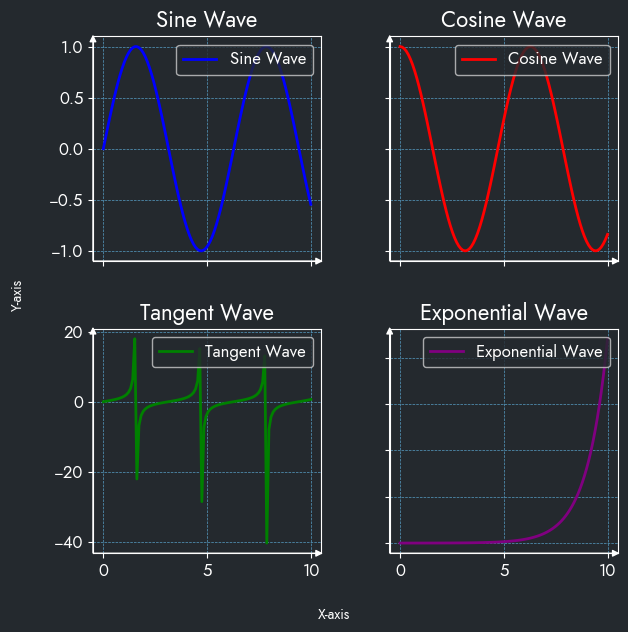

In [ ]:
# matplotlib with subplots
# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(6,6))
# Generate random data
x = np.linspace(0, 10, 100)
axs[0, 0].plot(x, np.sin(x), color='blue', label='Sine Wave')
axs[0, 0].set_title('Sine Wave')
axs[0, 1].plot(x, np.cos(x), color='red', label='Cosine Wave')
axs[0, 1].set_title('Cosine Wave')
axs[1, 0].plot(x, np.tan(x), color='green', label='Tangent Wave')
axs[1, 0].set_title('Tangent Wave')
axs[1, 1].plot(x, np.exp(x), color='purple', label='Exponential Wave')
axs[1, 1].set_title('Exponential Wave')
# Set common labels
fig.text(0.5, -0.04, 'X-axis', ha='center')
fig.text(-0.04, 0.5, 'Y-axis', va='center', rotation='vertical')
for sax in axs.flat:
    sax.label_outer()  # Hide inner labels
    sax.legend(loc='upper right')
    sax.grid(True)
    # aactivate the main axis lines
    #sax.spines['bottom'].set_visible(True)
    #sax.spines['left'].set_visible(True)
    #sax.spines['bottom'].set_color(primary_foreground)
    #sax.spines['left'].set_color(primary_foreground)
    # add an arrowhead to both axes
    sax.annotate('', xy=(1.02, 0), xytext=(-0.01, 0),
          arrowprops=dict(arrowstyle='-|>', color=primary_foreground, lw=1),
          xycoords='axes fraction', textcoords='axes fraction', clip_on=False)
    sax.annotate('', xy=(0, 1.02), xytext=(0.0, -0.01),
          arrowprops=dict(arrowstyle='-|>', color=primary_foreground, lw=1),
          xycoords='axes fraction', textcoords='axes fraction', clip_on=False)

# Adjust layout
plt.tight_layout()
# remove the space between the subplots
fig.subplots_adjust(hspace=0.3, wspace=0.3)
# Show the plot
plt.show()


# Other Packages
## Altair

Altair is a declarative statistical visualization library for Python, based on Vega and Vega-Lite visualization grammars.

Its primary features:

- Declarative (which is a kind of grammar)
- Interactive
- Loosely based on the Javascript Vega library

In [ ]:
import altair as alt

# Create a DataFrame for Altair
x = np.linspace(0.1, 10, 100)  # Avoid x=0 to prevent issues with exponentiation
df = pd.DataFrame({'x': x})

# Create a slider for the parameter 'a'
slider = alt.binding_range(min=0.1, max=5, step=0.1)
slider_param = alt.param(name='a', value=1, bind=slider)

# Create the Altair chart with detailed comments
chart = alt.Chart(df).mark_line(strokeWidth=3).encode(
  # Specify the x-axis encoding using the 'x' column from the DataFrame
  x='x',
  # Specify the y-axis encoding with a quantitative type and a custom title
  y=alt.Y('y:Q', title='y'),
  # Use a tooltip to display the x and y values when hovering over the line
  tooltip=[alt.Tooltip('x:Q', title='x-value'), alt.Tooltip('y:Q', title='y-value')],
).transform_calculate(
  # Use a JavaScript expression to calculate the y-values dynamically
  # 'datum.x' refers to the x-values in the DataFrame, and 'a' is the parameter controlled by the slider
  y='pow(datum.x, a)',
  legend_text='"y = x^" + a'  # Generate legend text dynamically
).add_params(
  # Add the slider parameters to the chart, allowing interactive control of the 'a' value
  slider_param
).properties(
  # Set the width and height of the chart for better visualization
  width=600,
  height=400,
  title='Interactive Plot with Altair'
).configure(
  # Configure the chart's background and other visual properties
  background=primary_background,
  title={
      'color': primary_foreground,
      'fontSize': 16
  },
  axis={
      'labelColor': primary_foreground,
      'titleColor': primary_foreground
  },
  legend={
      'labelColor': primary_foreground,
      'titleColor': primary_foreground
  }
).encode(
  # Add a legend with the formula as text
  color=alt.value('steelblue'),
  tooltip=[alt.Tooltip('y:Q', title='y-value')],
)

# Display the chart
chart.show()

alt.Chart(...)

## Seaborn

Primary Purpose: Statistical data visualization

Features:
- Built on top of Matplotlib
- Provides a high-level interface for drawing statistical graphics
- Additional functionality for visualizing distributions, relationships, and categorical data



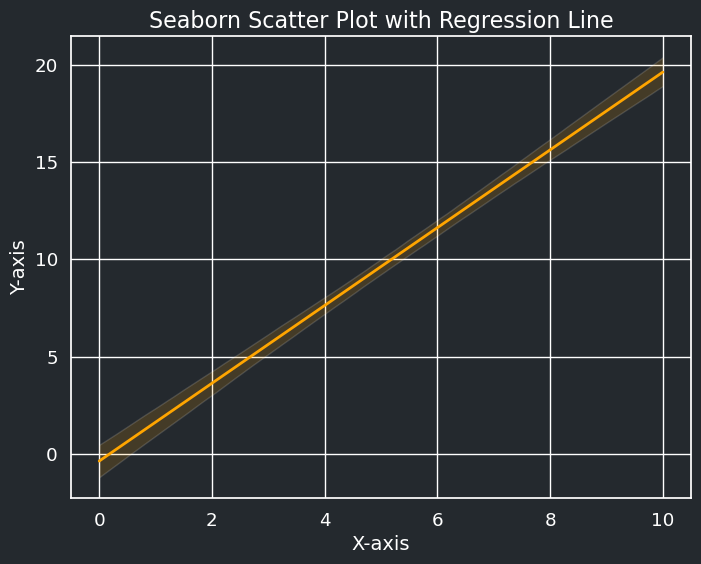

In [ ]:
# example plot using seaborn
import seaborn as sns

# Generate random data
x = np.linspace(0, 10, 100)
y = x * 2 - 0.4 + np.random.normal(0, 2, 100)
# Create a seaborn scatter plot
sns.set_context("notebook", font_scale=1.2)
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(8, 6))
#sns.scatterplot(x=x, y=y, color='steelblue', s=100, alpha=0.8, edgecolor=primary_foreground, linewidth=0.5)
# create a trend line regression fit
sns.regplot(x=x, y=y, scatter=False, color='orange', line_kws={'linewidth': 2})
# set the title and labels
ax.set_title('Seaborn Scatter Plot with Regression Line', fontsize=16, color=primary_foreground)
ax.set_xlabel('X-axis', fontsize=14, color=primary_foreground)
ax.set_ylabel('Y-axis', fontsize=14, color=primary_foreground)
# set the background color
ax.set_facecolor(primary_background)
# set total background color
fig.patch.set_facecolor(primary_background)
# set tick label colour
ax.tick_params(axis='x', colors=primary_foreground)
ax.tick_params(axis='y', colors=primary_foreground)

plt.show()

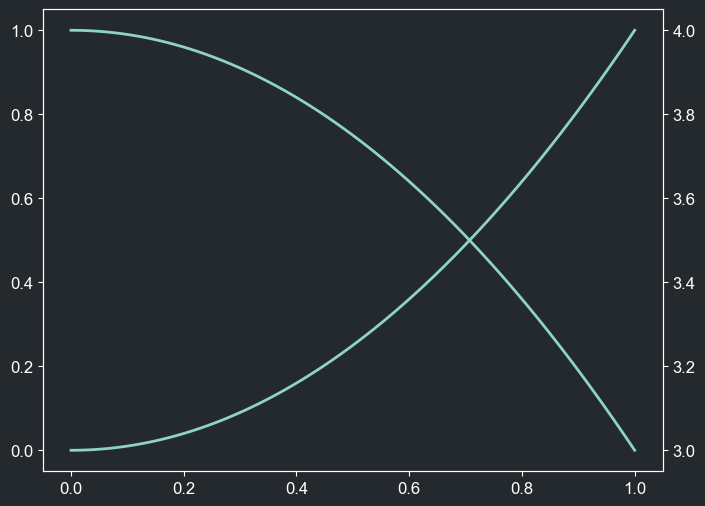

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
ax2 = ax.twinx()
x = np.linspace(0, 1, 100)
ax.plot(x, x**2)
ax2.plot(x, -x**2 + 4)
plt.show()

# Excercises

<table>
<tr>
<td>

### Exercise 1: tan(x)

- Create a plot of the function tan(x):

```python
x = np.linspace(0, 10, 100)
y = np.tan(x)
plt.plot(x, y)
```

- Use a line plot to visualize the function
- What is wrong here?
- Fix it!

### Exercise 2: boxplot distribution

- Create two distributions of N(0, 1) and N(2, 1)
- Create a boxplot of the two distributions
- What do you see?
- Create a boxplot of both distributions combined
- What do you see?
</td>
<td>

### Excercise 3: Subplots

- Create a figure with 4 subplots
- Create plots in each subplot
- Use different types of plots in each subplot
- Use different colors in each subplot

### Exercise 4: Customization

- Create a scatterplot of two distributions N([0, 1], [1, 1]) and N([2, 1], [1, 1])
- Customize the plot with different colors, line styles, and markers
- Add a title and labels to the axes
- Save the plot as a PNG file
- Save the plot as a PDF file

</td>
</tr>
</table>

# Excercise 5: Uncertainty plotting

```python
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(0, 10, 100)
y = np.where(x < 5, -x + np.random.normal(0, 3, x.shape), x + np.random.normal(0, 3, x.shape))
coeffs = np.polyfit(x, y, 1)
poly = np.poly1d(coeffs)
residuals = y - poly(x)
```

Using this code:
- Plot the data points
- Plot the polyfit
- Plot the uncertainty of the fit
- Add a text box with the coefficients of the fit, and the R^2 value


